## Question 1: How are video game sales geographically concentrated across the globe?

In [1]:
import pandas as pd
import plotly.express as px

# Load dataset
df = pd.read_csv('vgsales.csv')

# Total sales by region
sales_data = pd.DataFrame({
    'Region': ['North America', 'Europe', 'Japan', 'Other'],
    'Sales': [
        df['NA_Sales'].sum(),
        df['EU_Sales'].sum(),
        df['JP_Sales'].sum(),
        df['Other_Sales'].sum()
    ],

    # Simple coordinates for map
    'Latitude': [45, 50, 36, -15],
    'Longitude': [-100, 10, 138, -60]
})

# Create world map
fig = px.scatter_geo(
    sales_data,
    lat='Latitude',
    lon='Longitude',
    size='Sales',
    color='Region',
    hover_name='Region',
    title='Global Video Game Sales'
)

# Show map
fig.show()

# Q2: Platform Sales Analysis - BAR CHART----NAME:-



In [2]:
import pandas as pd
import plotly.express as px

# Load dataset
df = pd.read_csv('vgsales.csv')

# Top 15 platforms by sales
platform_sales = (
    df.groupby('Platform')['Global_Sales']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

# Create bar chart with values
fig = px.bar(
    x=platform_sales.index,
    y=platform_sales.values,
    text=platform_sales.values,   # show numbers on bars
    labels={'x': 'Platform', 'y': 'Global Sales'},
    title='Top 15 Platforms by Global Sales'
)

# Format numbers
fig.update_traces(texttemplate='%{text:.2f}', textposition='outside')

# Show graph
fig.show()

# Q3:*Which video game publishers have the highest global sales contribution?*


In [3]:
import pandas as pd
import plotly.express as px

# Load dataset
df = pd.read_csv('vgsales.csv')

# Top 10 publishers by global sales
publisher_sales = (
    df.groupby('Publisher')['Global_Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Create pie chart
fig = px.pie(
    values=publisher_sales.values,
    names=publisher_sales.index,
    title='Top 10 Publishers by Global Sales'
)

# Show percentage and values
fig.update_traces(
    textinfo='percent+label',
    hovertemplate='%{label}: %{value:.2f} Million'
)

# Show chart
fig.show()

## Question 4: How Have Sales Changed Over Time?

In [4]:
import pandas as pd
import plotly.express as px

# Load dataset
df = pd.read_csv('vgsales.csv')

# Total sales by year
yearly_sales = (
    df.groupby('Year')['Global_Sales']
    .sum()
)

# Create line chart
fig = px.line(
    x=yearly_sales.index,
    y=yearly_sales.values,
    markers=True,
    labels={'x': 'Year', 'y': 'Global Sales'},
    title='Global Video Game Sales Over Time'
)

# Show chart
fig.show()

# Peak sales year
peak_year = yearly_sales.idxmax()
peak_sales = yearly_sales.max()

print("Peak Year:", peak_year)
print("Highest Sales:", round(peak_sales, 2), "Million")

Peak Year: 2008.0
Highest Sales: 678.9 Million


## Question 5:  How has the market share of the top 5 genres evolved from the 1990s to the 2000s, and then to the 2010s?


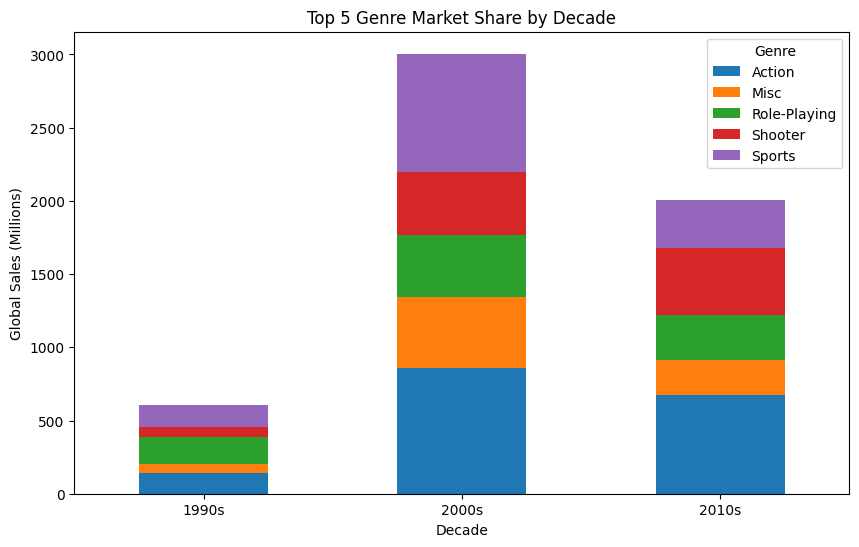

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('vgsales.csv')

# Remove missing years
df = df.dropna(subset=['Year'])

# Create decade column
def get_decade(year):
    if 1990 <= year < 2000:
        return '1990s'
    elif 2000 <= year < 2010:
        return '2000s'
    elif 2010 <= year < 2020:
        return '2010s'
    else:
        return None

df['Decade'] = df['Year'].apply(get_decade)

# Remove rows outside selected decades
df = df.dropna(subset=['Decade'])

# Find top 5 genres overall
top_genres = (
    df.groupby('Genre')['Global_Sales']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

# Keep only top genres
filtered_df = df[df['Genre'].isin(top_genres)]

# Sales by decade and genre
genre_sales = (
    filtered_df.groupby(['Decade', 'Genre'])['Global_Sales']
    .sum()
    .unstack()
)

# Create stacked bar chart
genre_sales.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

# Titles and labels
plt.title('Top 5 Genre Market Share by Decade')
plt.xlabel('Decade')
plt.ylabel('Global Sales (Millions)')

# Rotate labels
plt.xticks(rotation=0)

# Show legend
plt.legend(title='Genre')

# Show graph
plt.show()


## Question 6:How did global video game sales fluctuate over time, and what trends can be observed using a candlestick chart with volume analysis?

In [6]:
import pandas as pd
import plotly.graph_objects as go

# Load dataset
df = pd.read_csv('vgsales.csv')

# Remove missing years
df = df.dropna(subset=['Year'])

# Group sales by year
yearly_sales = (
    df.groupby('Year')['Global_Sales']
    .sum()
    .reset_index()
)

# Create OHLC values
yearly_sales['Open'] = yearly_sales['Global_Sales'].shift(1)
yearly_sales['Open'].fillna(yearly_sales['Global_Sales'], inplace=True)

yearly_sales['Close'] = yearly_sales['Global_Sales']

yearly_sales['High'] = yearly_sales[['Open', 'Close']].max(axis=1) + 20
yearly_sales['Low'] = yearly_sales[['Open', 'Close']].min(axis=1) - 20

# Create figure
fig = go.Figure()

# Candlestick chart
fig.add_trace(go.Candlestick(
    x=yearly_sales['Year'],
    open=yearly_sales['Open'],
    high=yearly_sales['High'],
    low=yearly_sales['Low'],
    close=yearly_sales['Close'],
    name='Sales Trend'
))

# Volume bars
fig.add_trace(go.Bar(
    x=yearly_sales['Year'],
    y=yearly_sales['Global_Sales'],
    name='Volume',
    opacity=0.3
))

# Layout
fig.update_layout(
    title='Global Video Game Sales Candlestick Chart with Volume',
    xaxis_title='Year',
    yaxis_title='Global Sales (Millions)',
    height=700
)

# Show chart
fig.show()

/var/folders/rx/14kl4rgs40q8f1khyy5xw_w00000gn/T/ipykernel_21944/2685024957.py:19: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  yearly_sales['Open'].fillna(yearly_sales['Global_Sales'], inplace=True)


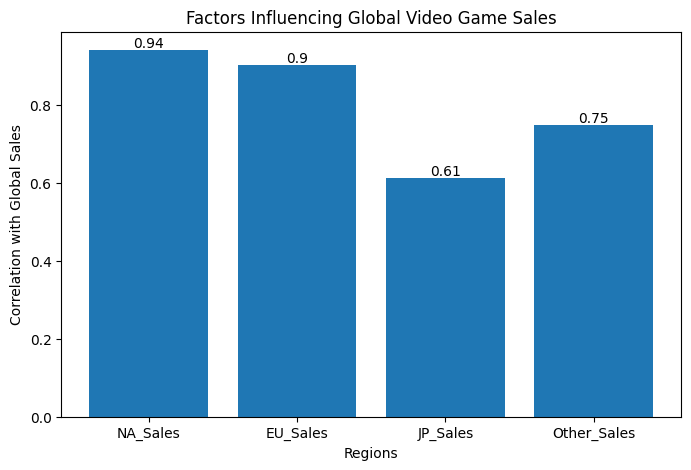

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('vgsales.csv')

# Select important factors
factors = [
    'NA_Sales',
    'EU_Sales',
    'JP_Sales',
    'Other_Sales'
]

# Calculate correlation with global sales
correlation = df[factors + ['Global_Sales']].corr()['Global_Sales'][:-1]

# Create bar chart
plt.figure(figsize=(8,5))

bars = plt.bar(
    correlation.index,
    correlation.values
)

# Add values on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        round(height, 2),
        ha='center',
        va='bottom'
    )

# Titles
plt.title('Factors Influencing Global Video Game Sales')
plt.xlabel('Regions')
plt.ylabel('Correlation with Global Sales')

# Show graph
plt.show()